In [19]:
import pandas as pd
from pathlib import Path
from sklearn import metrics
from sklearn.cluster import KMeans
from kneed import KneeLocator
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [20]:
data_dir = Path("data")
INDIR = Path("data/data_processed")
OUTDIR = Path("data/data_model")

OUTDIR.mkdir(parents=True, exist_ok=True)

In [21]:
arquivo = INDIR / "PARTICIPANTES_SIMPLIFICADO_TRATADO_MODELO.csv"
X_scaled = pd.read_csv(arquivo, encoding='utf-8')

X_sample = X_scaled.sample(frac=0.25, random_state=0)

In [22]:
X_scaled.head()

,RENDA_FAMILIAR_SM_LOG,IDADE_LOG,ESTADO_CIVIL_DIVORCIADO,ESTADO_CIVIL_SOLTEIRO,ESTADO_CIVIL_UNIAO,COR_RACA_AMARELA,COR_RACA_BRANCA,COR_RACA_INDÍGENA,COR_RACA_PARDA,COR_RACA_PRETA,SEXO_F,SEXO_M,REGIAO_CENTRO_OESTE,REGIAO_NORDESTE,REGIAO_NORTE,REGIAO_SUDESTE,REGIAO_SUL
0,-0.006023,0.151242,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
1,0.723128,2.529550,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
2,2.514581,2.529550,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
3,-0.006023,-0.586208,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1
4,0.723128,2.529550,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1


In [23]:
k_range = range(2, 11)
inertia_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    model.fit(X_sample)
    inertia_values.append(model.inertia_)

df_inertia = pd.DataFrame({
    'k': k_range,
    'inertia': inertia_values
}).set_index('k')

knee = KneeLocator(
    x=df_inertia.index,
    y=df_inertia['inertia'],
    curve='convex',
    direction='decreasing'
)

k_elbow = knee.knee

if k_elbow is None:
    print('Elbow não encontrado')
else:
    print(f'Elbow encontrado em k={k_elbow}')

Elbow encontrado em k=5


In [24]:
df_inertia.round(2)

,inertia
k,
2,2155324.13
3,1756651.63
4,1574986.31
5,1442525.75
6,1344118.41
7,1279020.80
8,1217430.37
9,1166866.57
10,1126998.79


In [25]:
k_range = range(2, 11)

ch_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    labels = model.fit_predict(X_sample)
    score = metrics.calinski_harabasz_score(X_sample, labels)
    ch_values.append(score)

df_ch = pd.DataFrame({
    'k': k_range,
    'calinski_harabasz': ch_values
}).set_index('k')

k_ch = df_ch['calinski_harabasz'].idxmax()
print(f"Melhor valor de k (Calinski-Harabasz): {k_ch}")

Melhor valor de k (Calinski-Harabasz): 3


In [26]:
df_ch.round(2)

,calinski_harabasz
k,
2,165432.13
3,179338.73
4,159726.89
5,146544.55
6,135864.32
7,124802.21
8,117343.24
9,110840.49
10,104706.63


In [27]:
k_range = range(2, 11)
db_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    labels = model.fit_predict(X_sample)
    score = metrics.davies_bouldin_score(X_sample, labels)
    db_values.append(score)

df_db = pd.DataFrame({
    'k': k_range,
    'davies_bouldin': db_values
}).set_index('k')

k_db = df_db['davies_bouldin'].idxmin()
print(f"Melhor valor de k (Davies-Bouldin): {k_db}")

Melhor valor de k (Davies-Bouldin): 8


In [28]:
df_db.round(2)

,davies_bouldin
k,
2,1.64
3,1.65
4,1.67
5,1.58
6,1.55
7,1.61
8,1.46
9,1.62
10,1.80


In [35]:
k_range = range(2, 11)
silhouette_values = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=0,
        max_iter=200
    )
    
    labels = model.fit_predict(X_sample)

    score = metrics.silhouette_score(
        X_sample,
        labels,
        sample_size=5000,
        random_state=0
    )
    
    silhouette_values.append(score)

df_silhouette = pd.DataFrame({
    'k': k_range,
    'silhouette': silhouette_values
}).set_index('k')

k_sil = df_silhouette['silhouette'].idxmax()
k_sil

2

In [33]:
df_silhouette

,silhouette
k,
2,0.245798
3,0.196143
4,0.188718
5,0.206931
6,0.194628
7,0.204491
8,0.222729
9,0.218475
10,0.201225


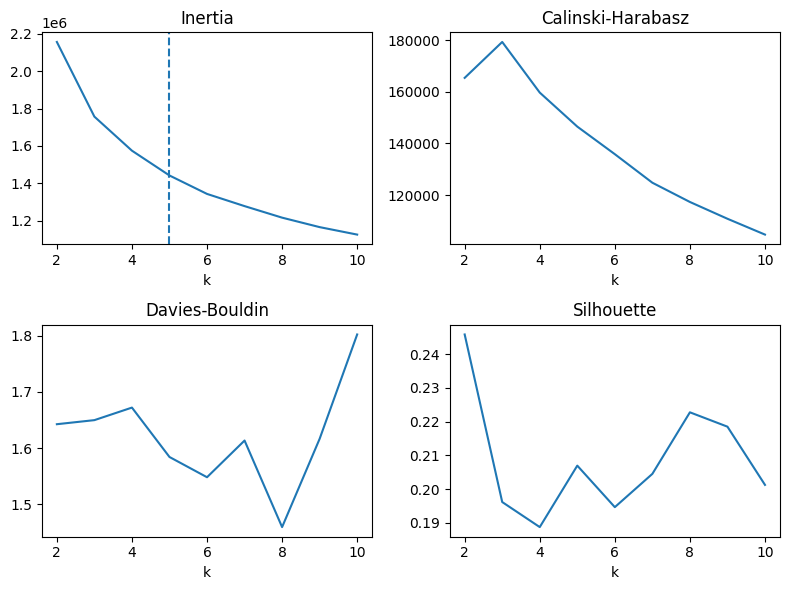

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))


df_inertia['inertia'].plot(ax=axes[0, 0], title='Inertia')

if k_elbow is not None:
    axes[0, 0].axvline(k_elbow, linestyle='--')


df_ch['calinski_harabasz'].plot(ax=axes[0, 1], title='Calinski-Harabasz')

df_db['davies_bouldin'].plot(ax=axes[1, 0], title='Davies-Bouldin')

df_silhouette['silhouette'].plot(ax=axes[1, 1], title='Silhouette')

plt.tight_layout()